In [35]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt

In [2]:
# Please refer to BED file format
# https://en.wikipedia.org/wiki/BED_(file_format)

def load_data(file_name):
    columns = ['chrom', 'chromStart', 'chromEnd', 'name']
    df = pd.read_csv(file_name, sep="\t", header=None, names=columns)
    return df

In [22]:
def load_gene_reviews(file_name):
    df = pd.read_csv(file_name, header="infer")
    return df

In [3]:
h3k4me3_df = load_data("dataset/HepG2_Male.histone.H3K4me3.peak.bed")
h3k9ac_df = load_data("dataset/HepG2_Male.histone.H3K9ac.peak.bed")
h3k27ac_df = load_data("dataset/HepG2_Male.histone.H3K27ac.peak.bed")
h3k27me3_df = load_data("dataset/HepG2_Male.histone.H3K27me3.peak.bed")
h3k9me3_df = load_data("dataset/HepG2_Male.histone.H3K9me3.peak.bed")

In [4]:
h3k4me3_df.head()

,chrom,chromStart,chromEnd,name
0,chr10,119808,119954,chr10_173
1,chr10,119956,120102,chr10_174
2,chr10,122100,122246,chr10_185
3,chr10,122308,122454,chr10_186
4,chr10,180346,180492,chr10_489


In [6]:
h3k9ac_df.head()

,chrom,chromStart,chromEnd,name
0,chr10,119956,120102,chr10_174
1,chr10,122100,122246,chr10_185
2,chr10,122308,122454,chr10_186
3,chr10,180538,180684,chr10_490
4,chr10,181013,181159,chr10_491


In [7]:
h3k27ac_df.head()

,chrom,chromStart,chromEnd,name
0,chr10,181013,181159,chr10_491
1,chr10,181613,181759,chr10_492
2,chr10,181753,181899,chr10_493
3,chr10,182018,182164,chr10_494
4,chr10,354743,354889,chr10_1382


In [8]:
h3k27me3_df.head()

,chrom,chromStart,chromEnd,name
0,chr10,93323,93469,chr10_48
1,chr10,102468,102614,chr10_88
2,chr10,138398,138544,chr10_274
3,chr10,168648,168794,chr10_431
4,chr10,315893,316039,chr10_1171


In [9]:
h3k9me3_df.head()

,chrom,chromStart,chromEnd,name
0,chr10,104133,104279,chr10_97
1,chr10,149783,149929,chr10_336
2,chr10,229638,229784,chr10_735
3,chr10,232118,232264,chr10_748
4,chr10,234923,235069,chr10_765


In [10]:
frames = [h3k4me3_df, h3k9ac_df, h3k27ac_df, h3k27me3_df, h3k9me3_df]
histone_df = pd.concat(frames)
histone_df.head()

,chrom,chromStart,chromEnd,name
0,chr10,119808,119954,chr10_173
1,chr10,119956,120102,chr10_174
2,chr10,122100,122246,chr10_185
3,chr10,122308,122454,chr10_186
4,chr10,180346,180492,chr10_489


In [13]:
print(histone_df.shape)

(319086, 4)


In [27]:
histone_df.describe()

,chromStart,chromEnd
count,3.190860e+05,3.190860e+05
mean,7.568847e+07,7.568862e+07
std,5.573188e+07,5.573188e+07
min,6.893000e+03,7.039000e+03
25%,3.228027e+07,3.228041e+07
50%,6.304105e+07,6.304120e+07
75%,1.112144e+08,1.112145e+08
max,2.492390e+08,2.492392e+08


In [29]:
# Bucketing
bucket_size = 2000
min = 0
max = histone_df['chromEnd'].max()

bins = np.arange(min, max + bucket_size, bucket_size)
print(bins)

[        0      2000      4000 ... 249236000 249238000 249240000]


In [33]:
# Do the binning
histone_df["bucket"] = pd.cut(histone_df['chromStart'], bins)
histone_df.head()

,chrom,chromStart,chromEnd,name,bucket
0,chr10,119808,119954,chr10_173,"(118000, 120000]"
1,chr10,119956,120102,chr10_174,"(118000, 120000]"
2,chr10,122100,122246,chr10_185,"(122000, 124000]"
3,chr10,122308,122454,chr10_186,"(122000, 124000]"
4,chr10,180346,180492,chr10_489,"(180000, 182000]"


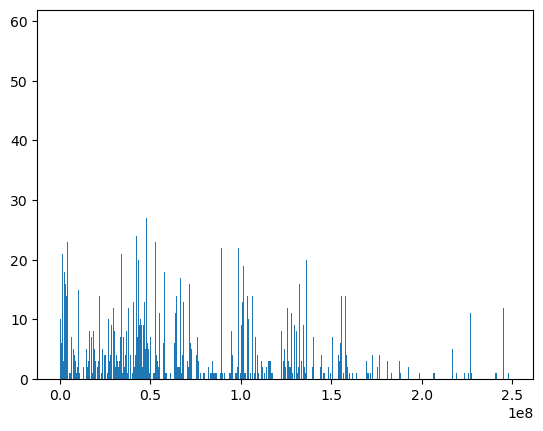

In [36]:
plt.hist(histone_df['chromStart'], bins)
plt.show()

In [ ]:
# Join the histone_df with gene_reviews

In [23]:
gene_reviews_df = load_gene_reviews("dataset/gene_reviews.csv")
gene_reviews_df.head()

,bin,chrom,chromStart,chromEnd,name,grShort,grTitle
0,21,chr9,104781005,104928155,ABCA1,tangier,Tangier Disease
1,34,chr2,214931541,215138626,ABCA12,li-ar,Autosomal Recessive Congenital Ichthyosis
2,162,chr1,93992833,94121148,ABCA4,rp-overview,Nonsyndromic Retinitis Pigmentosa Overview
3,144,chrX,75051047,75156283,ABCB7,sider-anemia,X-Linked Sideroblastic Anemia and Ataxia
4,708,chr16,16148927,16223464,ABCC6,gaci,Generalized Arterial Calcification of Infancy


In [26]:
gene_reviews_df.sort_values(by='chromStart', ascending=True, inplace=True)
gene_reviews_df.head()

,bin,chrom,chromStart,chromEnd,name,grShort,grTitle
1122,585,chr20_KI270871v1_alt,182,33239,KCNQ2,bfns,KCNQ2-Related Disorders
1331,585,chrM,576,647,MT-TF,mt-overview,Mitochondrial Disorders Overview
1330,585,chrM,576,647,MT-TF,merrf,MERRF
1329,585,chrM,576,647,MT-TF,melas,MELAS
1324,585,chrM,647,1601,MT-RNR1,mt-deafness,"Nonsyndromic Hearing Loss and Deafness, Mitoch..."
